In [1]:
! pip install filterpy control

In [2]:
import torch
import torch.nn as nn
import pandas as pd
from google.colab import drive
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import math
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise
import control
import tensorflow as tf
from torch.optim import lr_scheduler
from google.colab import files


In [3]:
load_previous_data = True
drive.mount('/content/drive')


x0 = np.array([1.171590840448506 , 0 ,0.088096915825144, 0.0, -0.189065015297496, 0.0])
x0_t = np.array([1.096338870039341 ,  -0.063061373962493 , -0.041124589315359,   -0.019836830671163  , 0.193161660238782, -0.099631996708425])

def generate_control_data(x0_c,x0_t ,t_start,t_end, dt):
  m_moon    = 7.34767309e22  #kg
  m_earth   = 5.9742e24      #kg
  mu   = m_moon/(m_moon + m_earth)
  # states = np.zeros((math.ceil((t_end-t_start)/dt), 9))
  time = np.arange(t_start, t_end, dt)
  K = 1.0e+02 * np.array([
        [3.242230263618859, -0.157426908405593, -0.018336238988270, 0.406006889674832, 0.000070014815797, -0.000453116144559],
        [0.157476236062220, 3.128310921790005, -0.000369603161063, 0.000070014815798, 0.403198479658686, -0.000011281905019],
        [-0.018354476104479, 0.000362851980636, 3.129947581668201, -0.000453116144559, -0.000011281905019, 0.403235348390790]
        ])
  X_t = x0_t
  X_c = x0_c
  x,y,z,dx,dy,dz = X_c
  x_t,y_t,z_t,dx_t,dy_t,dz_t = X_t
  input_sequence = []
  output_sequence = []
  input_samples = []
  output_samples = []
  for i in range(len(time)):


      error = X_t - X_c

      if np.random.rand() < 0.9:
        u = K @ error
      else:
        u = np.random.uniform(-10, 10, size=(3,))
      u1,u2,u3 = u

      r1_x = x + mu
      r1_y = y
      r1_z = z
      r2_x = x - (1 - mu)
      r2_y = y
      r2_z = z

      nr1 = np.sqrt(r1_x**2 + r1_y**2 + r1_z**2)
      nr2 = np.sqrt(r2_x**2 + r2_y**2 + r2_z**2)

      ddx = 2 * dy + x - ((1 - mu) / nr1**3) * r1_x - (mu / nr2**3) * r2_x + u1
      ddy = -2 * dx + y - ((1 - mu) / nr1**3) * r1_y - (mu / nr2**3) * r2_y + u2
      ddz = -((1 - mu) / nr1**3) * r1_z - (mu / nr2**3) * r2_z + u3

      dx += dt * ddx
      dy += dt * ddy
      dz += dt * ddz

      x += dt * dx
      y += dt * dy
      z += dt * dz

      X_c = np.array([x,y,z,dx,dy,dz])

      r1_x = x_t + mu
      r1_y = y_t
      r1_z = z_t
      r2_x = x_t - (1 - mu)
      r2_y = y_t
      r2_z = z_t

      nr1 = np.sqrt(r1_x**2 + r1_y**2 + r1_z**2)
      nr2 = np.sqrt(r2_x**2 + r2_y**2 + r2_z**2)


      ddx_t = 2 * dy_t + x_t - ((1 - mu) / nr1**3) * r1_x - (mu / nr2**3) * r2_x
      ddy_t = -2 * dx_t + y_t - ((1 - mu) / nr1**3) * r1_y - (mu / nr2**3) * r2_y
      ddz_t = -((1 - mu) / nr1**3) * r1_z - (mu / nr2**3) * r2_z

      dx_t += dt * ddx_t
      dy_t += dt * ddy_t
      dz_t += dt * ddz_t

      x_t += dt * dx_t
      y_t += dt * dy_t
      z_t += dt * dz_t

      X_t = np.array([x_t,y_t,z_t,dx_t,dy_t,dz_t])
      input_state = np.hstack(( X_c[:3] + + 0.0001 * np.random.normal(0,1,(3,) ) ,u))
      output_state =  X_c
      input_sequence.append(input_state)
      if len( input_sequence)>=100:
        input_samples.append(np.array(input_sequence))
        output_samples.append(output_state)
        input_sequence = input_sequence[1:]

  return np.array(input_samples),np.array(output_samples)[:, np.newaxis, :]

if load_previous_data:
  x_train = np.load('/content/drive/MyDrive/x_train.npy')
  y_train = np.load('/content/drive/MyDrive/y_train.npy')
  x_tv,y_tv = generate_control_data(x0,x0_t, t_start=0, t_end=.1, dt = 0.00001)
else:
   x_train,y_train = generate_control_data(x0,x0_t, t_start=0, t_end = 10, dt = 0.00001)
   np.save('/content/drive/MyDrive/x_train.npy', x_train)
   np.save('/content/drive/MyDrive/y_train.npy', y_train)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size[0], num_layers=num_layers, batch_first=True, dropout=0.8)
        # self.lstm = nn.LSTM(input_size, output_size, num_layers=num_layers, batch_first=True, dropout=0.8)
        self.batch_norm1 = nn.BatchNorm1d(hidden_size[0])
        self.fc1 = nn.Linear(hidden_size[0], output_size)
        self.batch_norm2 = nn.BatchNorm1d(hidden_size[1]) #
        self.fc2 = nn.Linear(hidden_size[1], hidden_size[2])
        self.batch_norm3= nn.BatchNorm1d(hidden_size[2])
        self.fc3 = nn.Linear(hidden_size[2],output_size)
        self.activation = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc1(lstm_out[:, -1, :])

        return out

def calculate_mape(y_true, y_pred):
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [5]:
class Model:
    def __init__(self, model_type, dt = 0.0001):
        self.dt = dt
        self.model_type = model_type
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = None
        self.A = np.array([
            [0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1],
            [8.274, 0, -1.821, 0, 2, 0],
            [0, -3.019, 0, -2, 0, 0],
            [-1.821, 0, -3.255, 0, 0, 0]
        ])

    def pre_process(self,x_train,y_train,x_tv,y_tv, test_size=00.4, noise_power=0.000001, normalization=False):

        x_val, x_test, y_val, y_test = train_test_split(x_tv,  y_tv, test_size=test_size, shuffle=False)
        self.noise_power = noise_power
        # self.scaler = loaded_scaler
        # if normalization:
        #     x_train = self.scaler.transform(x_train)
        #     x_val = self.scaler.transform(x_val)
        #     x_test = self.scaler.transform(x_test)

        self.x_train_tensor = torch.tensor(x_train, dtype=torch.float32).to(self.device)
        self.y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(self.device)
        self.x_val_tensor = torch.tensor(x_val, dtype=torch.float32).to(self.device)
        self.y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(self.device)
        self.x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to(self.device)
        self.y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(self.device)


    def train(self, hidden_size=[32,16,8], learning_rate=0.005, num_epochs=2000, load_previous=True,batch_size = 512):
        if self.model_type == 'LSTM':
            input_size = self.x_train_tensor.shape[-1]
            output_size = self.y_train_tensor.shape[-1]
            self.model = LSTMModel(input_size, hidden_size, output_size).to(self.device)
            if load_previous:
                drive.mount('/content/drive')
                model_path = '/content/drive/My Drive/bilstm_model_control61.pth'
                self.model.load_state_dict(torch.load(model_path, map_location=self.device))
                self.model.eval()
            else:
                criterion = nn.MSELoss()
                optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
                scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)  # Reduce the learning rate by a factor of 10 every 10 epochs
                self.losses = []
                self.val_losses = []
                mape_scores = []

                train_dataset = TensorDataset(self.x_train_tensor, self.y_train_tensor)
                train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

                val_dataset = TensorDataset(self.x_val_tensor, self.y_val_tensor)
                val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

                for epoch in range(num_epochs):
                    self.model.train()
                    total_loss = 0
                    for batch_x, batch_y in train_dataloader:
                        batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                        optimizer.zero_grad()
                        output = self.model(batch_x)
                        loss = criterion(output, batch_y.squeeze(1))
                        loss.backward()
                        optimizer.step()


                        total_loss += loss.item()
                    scheduler.step()
                    avg_loss = total_loss / len(train_dataloader)
                    self.losses.append(avg_loss)

                    self.model.eval()
                    with torch.no_grad():
                        val_loss = 0
                        epoch_mape = []
                        for val_x, val_y in val_dataloader:
                            val_output = self.model(val_x)
                            val_loss += criterion(val_output, val_y.squeeze(1)).item()
                            mape_score = calculate_mape(val_y.squeeze(1).cpu().numpy(), val_output.cpu().numpy())
                            epoch_mape.append(mape_score)
                        val_loss /= len(val_dataloader)
                        avg_mape = np.mean(epoch_mape)
                        self.val_losses.append(val_loss)
                        mape_scores.append(avg_mape)
                    if (epoch + 1) % 10 == 0:
                        model_path = '/content/drive/My Drive/bilstm_model_control61th'
                        torch.save(self.model.state_dict(), model_path)
                      # print(f'Model saved to {model_path}')
                        print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_loss:.4f}, Validation MAPE: {avg_mape:.4f}%')


        else:
            self.model = KalmanFilter(dim_x=6, dim_z=3)
            # self.model.F = np.identity(6) + self.A * self.dt
            self.model.F =  self.A
            self.model.H = np.zeros((3, 6))
            self.model.H[:, :3] = np.identity(3)
            self.model.P *= 100

            self.model.Q = 1*np.diag([1000, 1000, 1000, 1, 1, 1])
            self.model.R =0.00001* np.diag([1,1,1])
            self.model.x = x0

    def predict(self, x):
        if self.model_type == 'LSTM':
            self.model.eval()
            with torch.no_grad():
                return self.model(x).to(self.device)


        else:
            self.model.predict()
            self.model.update(torch.tensor(x).cpu())
            return torch.tensor(self.model.x, dtype=torch.float32).to(self.device)


    def test_results(self):
        y_test = self.y_test_tensor.cpu().numpy()
        if self.model_type == 'LSTM':

            y_hat = self.predict(self.x_test_tensor).cpu().numpy()

            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            titles = ['x', 'y', 'z', 'dx', 'dy', 'dz']
            y_labels = ['Position x', 'Position y', 'Position z', 'Velocity dx', 'Velocity dy', 'Velocity dz']

            for i in range(6):
                ax = axes[i // 3, i % 3]
                ax.plot(y_test[:, -1,i], label='True', color='blue' )
                ax.plot(y_hat[:,i], label='Predicted', color='red')
                ax.set_title(f'True vs Predicted {titles[i]}')
                ax.set_xlabel('Time step')
                ax.set_ylabel(y_labels[i])
                ax.legend()
                ax.grid(True)

            plt.tight_layout()
            plt.show()

        else:
            y_hats = []
            for x in self.x_test_tensor[:,-1,:3]:
                y_hat = self.predict(x)
                self.model.x = y_hat
                y_hats.append(y_hat.cpu())

            y_hats = np.array(y_hats)

            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            titles = ['x', 'y', 'z', 'dx', 'dy', 'dz']
            y_labels = ['Position x', 'Position y', 'Position z', 'Velocity dx', 'Velocity dy', 'Velocity dz']

            for i in range(6):
                ax = axes[i // 3, i % 3]
                ax.plot(y_test[:,-1, i], label='True', color='blue')
                ax.plot(y_hats[:, i], label='Predicted', color='red')
                ax.set_title(f'True vs Predicted {titles[i]}')
                ax.set_xlabel('Time step')
                ax.set_ylabel(y_labels[i])
                ax.legend()
                ax.grid(True)

            plt.tight_layout()
            plt.show()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.8 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-6-824cda082418>:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path, map_location=self.device))


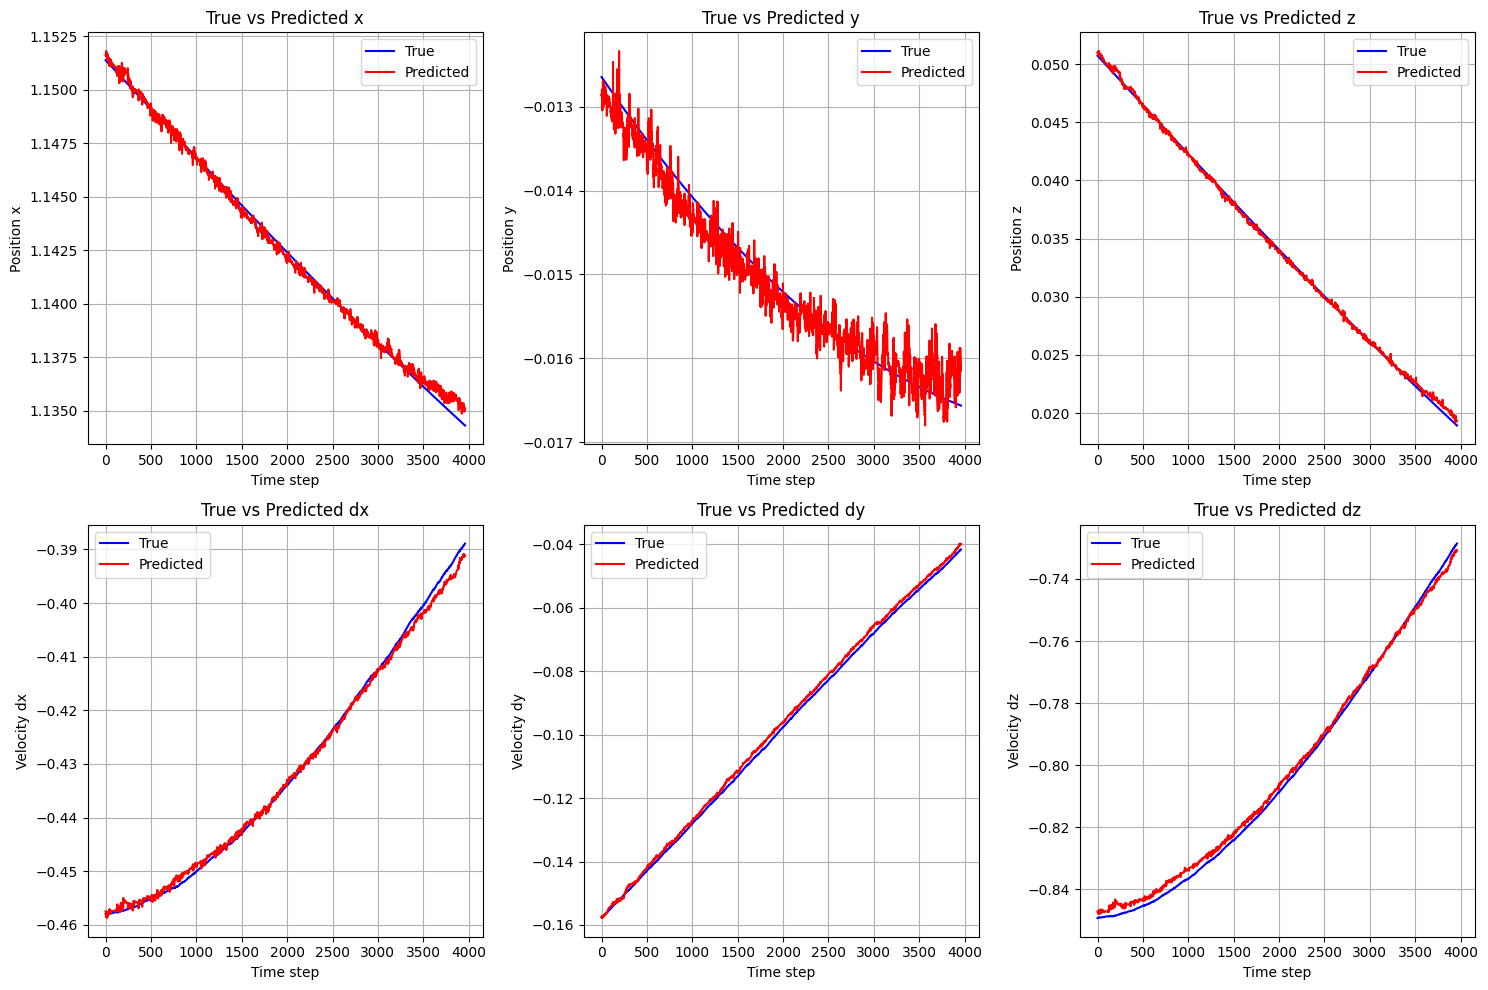

In [7]:
model_type='LSTM'
load_previous= True

if load_previous == False:
  lstm_model = Model(model_type='LSTM')
  lstm_model.pre_process(x_train,y_train,x_tv,y_tv,)
  lstm_model.train(load_previous=load_previous)
  drive.mount('/content/drive')
  model_path = '/content/drive/My Drive/bilstm_model_control62.pth'
  torch.save(lstm_model.model.state_dict(), model_path)
  print(f'Model saved to {model_path}')
else:
  lstm_model = Model(model_type= model_type)
  lstm_model.pre_process(x_train,y_train,x_tv,y_tv)
  lstm_model.train(load_previous=True)
  lstm_model.test_results()








<ipython-input-5-a2fea51f88f3>:116: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.update(torch.tensor(x).cpu())


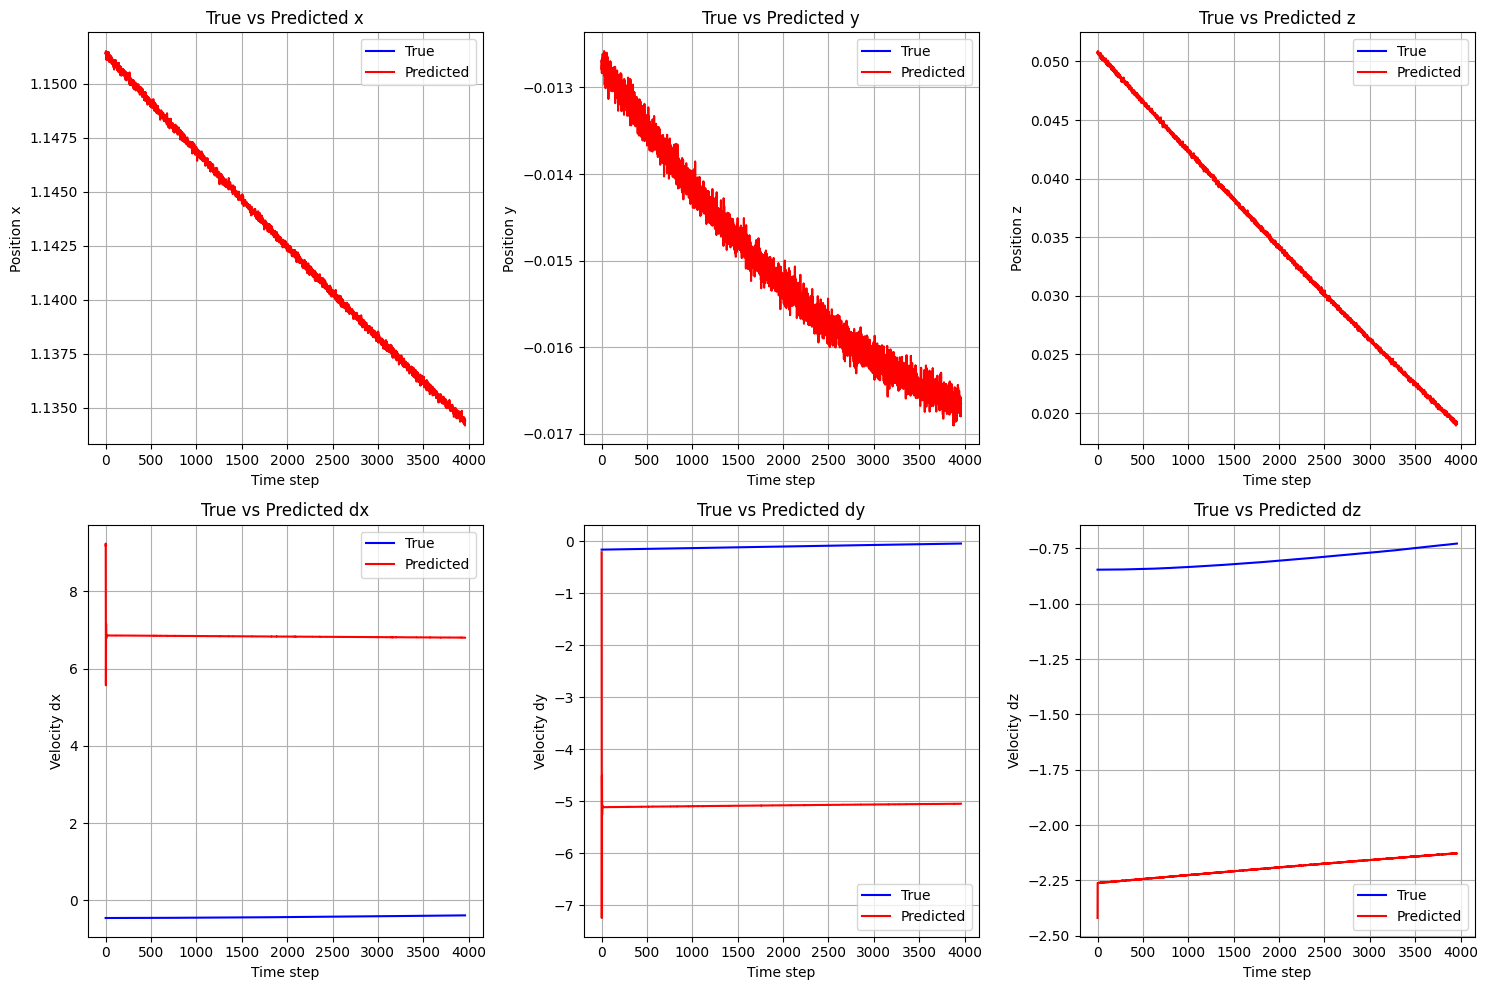

In [6]:
model_type='Kalman filter'
kalman_model = Model(model_type=model_type)
kalman_model.pre_process(x_train,y_train,x_tv,y_tv)
kalman_model.train()
kalman_model.test_results()

In [6]:
class SpacecraftRendezvousEnv():
    def __init__(self, dt):
        super(SpacecraftRendezvousEnv, self).__init__()

        # Define constants
        m_moon    = 7.34767309e22;  #kg
        m_earth   = 5.9742e24;      #kg
        self.mu   = m_moon/(m_moon + m_earth);
        self.dt = dt
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.reset()
        self.DU        = 384402  #km
        self.TU        = 27.3216*3600*24/(2*np.math.pi)  #sec


    def step(self, action,stimate = False):
        x, y, z, dx, dy, dz = np.array(self.chaser_state.cpu())

        u1, u2, u3 = action

        r1_x = x + self.mu
        r1_y = y
        r1_z = z
        r2_x = x - (1 - self.mu)
        r2_y = y
        r2_z = z

        nr1 = np.sqrt(r1_x**2 + r1_y**2 + r1_z**2)
        nr2 = np.sqrt(r2_x**2 + r2_y**2 + r2_z**2)

        ddx = 2 * dy + x - ((1 - self.mu) / nr1**3) * r1_x - (self.mu / nr2**3) * r2_x + u1
        ddy = -2 * dx + y - ((1 - self.mu) / nr1**3) * r1_y - (self.mu / nr2**3) * r2_y + u2
        ddz = -((1 - self.mu) / nr1**3) * r1_z - (self.mu / nr2**3) * r2_z +u3

        dx += self.dt * ddx
        dy += self.dt * ddy
        dz += self.dt *ddz

        x += self.dt *dx
        y += self.dt *dy
        z += self.dt *dz

        self.chaser_state = torch.tensor([x, y, z, dx, dy, dz], device=self.device, dtype=torch.float32)



        target_x, target_y, target_z, target_dx, target_dy, target_dz = np.array(self.target_state.cpu())

        r1_x = target_x + self.mu
        r1_y = target_y
        r1_z = target_z
        r2_x = target_x - (1 - self.mu)
        r2_y = target_y
        r2_z = target_z

        nr1 = np.sqrt(r1_x**2 + r1_y**2 + r1_z**2)
        nr2 = np.sqrt(r2_x**2 + r2_y**2 + r2_z**2)

        target_ddx = 2 * target_dy + target_x - ((1 - self.mu) / nr1**3) * r1_x - (self.mu / nr2**3) * r2_x
        target_ddy = -2 * target_dx + target_y - ((1 - self.mu) / nr1**3) * r1_y - (self.mu / nr2**3) * r2_y
        target_ddz = -((1 - self.mu) / nr1**3) * r1_z - (self.mu / nr2**3) * r2_z

        target_dx += self.dt *target_ddx
        target_dy += self.dt *target_ddy
        target_dz += self.dt *target_ddz

        target_x += self.dt *target_dx
        target_y += self.dt *target_dy
        target_z += self.dt *target_dz

        self.target_state = torch.tensor([target_x, target_y, target_z, target_dx, target_dy, target_dz],device=self.device, dtype=torch.float32)


    def reset(self):
        # Reset the spacecraft states to initial positions
        self.chaser_state = torch.tensor([1.171590840448506 , 0 ,0.088096915825144, 0.0, -0.189065015297496, 0.0], device=self.device, dtype=torch.float32)
        # self.chaser_state = torch.tensor([0.863208079432151, 0.061337921603600, -0.024420122752106, 0.033284673232270,  -0.108377133230406, -0.099921371148358], device=self.device, dtype=torch.float32)
        # self.target_state = torch.tensor([0.824110000000000, 0.0,0.0562535666081773, 0.0,0.166629870026402, 0.0], device=self.device, dtype=torch.float32)
        # self.target_state = torch.tensor([0.863208079432151, 0.06133792160/3600, -0.024420122752106, 0.033284673232270,  -0.108377133230406, -0.099921371148358], device=self.device, dtype=torch.float32)
        self.target_state = torch.tensor([1.096338870039341 ,  -0.063061373962493 , -0.041124589315359,   -0.019836830671163  , 0.193161660238782, -0.099631996708425], device=self.device, dtype=torch.float32)

In [7]:
class Control:
    def __init__(self, model_type, env):

      self.model_type = model_type
      self.stimator = Model(model_type= self.model_type)
      self.stimator.pre_process(x_train,y_train,x_tv,y_tv,)
      self.stimator.train(load_previous=True)
      self.A = self.stimator.A
      self.B = np.array([[0,0,0],[0,0,0],[0,0,0],[1,0,0],[0,1,0],[0,0,1]])
      self.T = 1 # duration of rendezvous
      self.dt = env.dt
      self.environment = env
      # self.noise_power = self.stimator.noise_power
      # self.scaler = self.stimator.scaler
      self.device = self.stimator.device
      self.measure = 'chaser'
      self.normalization = False
    def LQR(self, Q, R):
        chaser_states, target_states, y_hats = torch.zeros(int(self.T/self.dt),6).to(self.device), torch.zeros(int(self.T/self.dt),6).to(self.device), torch.zeros(int(self.T/self.dt),6).to(self.device)
        actions = np.zeros((int(self.T/self.dt),3))
        actions[0] = np.array([0,0,0])
        y_hats[0] = self.environment.chaser_state
        chaser_states[0], target_states[0] = self.environment.chaser_state, self.environment.target_state
        K, S, E = control.lqr(self.A, self.B, Q, R)
        chaser_measures = []
        j = 0
        for i in range(int(self.T/self.dt)-1):
            if self.measure == 'chaser':
              chaser_measure = self.environment.chaser_state[:3].clone() #+ torch.tensor(self.noise_power * np.random.normal(0, 1, self.environment.chaser_state[:3].shape), device=self.device, dtype=torch.float32)
              if self.model_type == 'LSTM':
                chaser_measure = np.hstack((chaser_measure.cpu().numpy() ,np.array(actions[i])))
                if len(chaser_measures)<100:
                  chaser_measures.append(chaser_measure)
                  y_hat = self.environment.chaser_state.clone()
                  error = self.environment.target_state - y_hat
                  action = K @ np.transpose(error.detach().cpu().numpy())
                  actions[i+1] = action
                  y_hats[i+1] = y_hat
                  self.environment.step(action)
                else:
                  chaser_measures = chaser_measures[1:]
                  chaser_measures.append(chaser_measure)
                  y_hat =  self.stimator.predict(torch.tensor(np.array([chaser_measures]), device=self.device, dtype=torch.float32).clone())
                  y_hat = y_hat.squeeze(0)
                  y_hat = torch.cat((self.environment.chaser_state[:3], y_hat[3:]), dim=0)
                  error = self.environment.target_state - y_hat
                  action = K @ np.transpose(error.detach().cpu().numpy())
                  actions[i+1] = action
                  y_hats[i+1] = y_hat
                  self.environment.step(action)


            chaser_states[i+1] = self.environment.chaser_state
            target_states[i+1] = self.environment.target_state
        return chaser_states, target_states,actions, y_hats


In [12]:
del chaser_states, target_states, actions, y_hats

In [8]:
dt = 0.00001
env = SpacecraftRendezvousEnv(dt)
control_method =  'LQR'
model_type ='LSTM'
cont = Control(model_type, env)
if control_method ==  'LQR':



  R =  0.001* np.diag([1, 1, 1])
  Q = 1 * np.array([[100, 0, 0, 0, 0, 0],
                      [0, 100, 0, 0, 0, 0],
                      [0, 0, 100, 0, 0, 0],
                      [0, 0, 0, 1, 0, 0],
                      [0, 0, 0, 0, 1, 0],
                      [0, 0, 0, 0, 0, 1]]) # for lstm


  chaser_states, target_states, actions, y_hats = cont.LQR(Q, R)


<ipython-input-6-ad7a5abe5b35>:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  self.TU        = 27.3216*3600*24/(2*np.math.pi)  #sec
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.8 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-5-a2fea51f88f3>:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path, map_location=self.device))


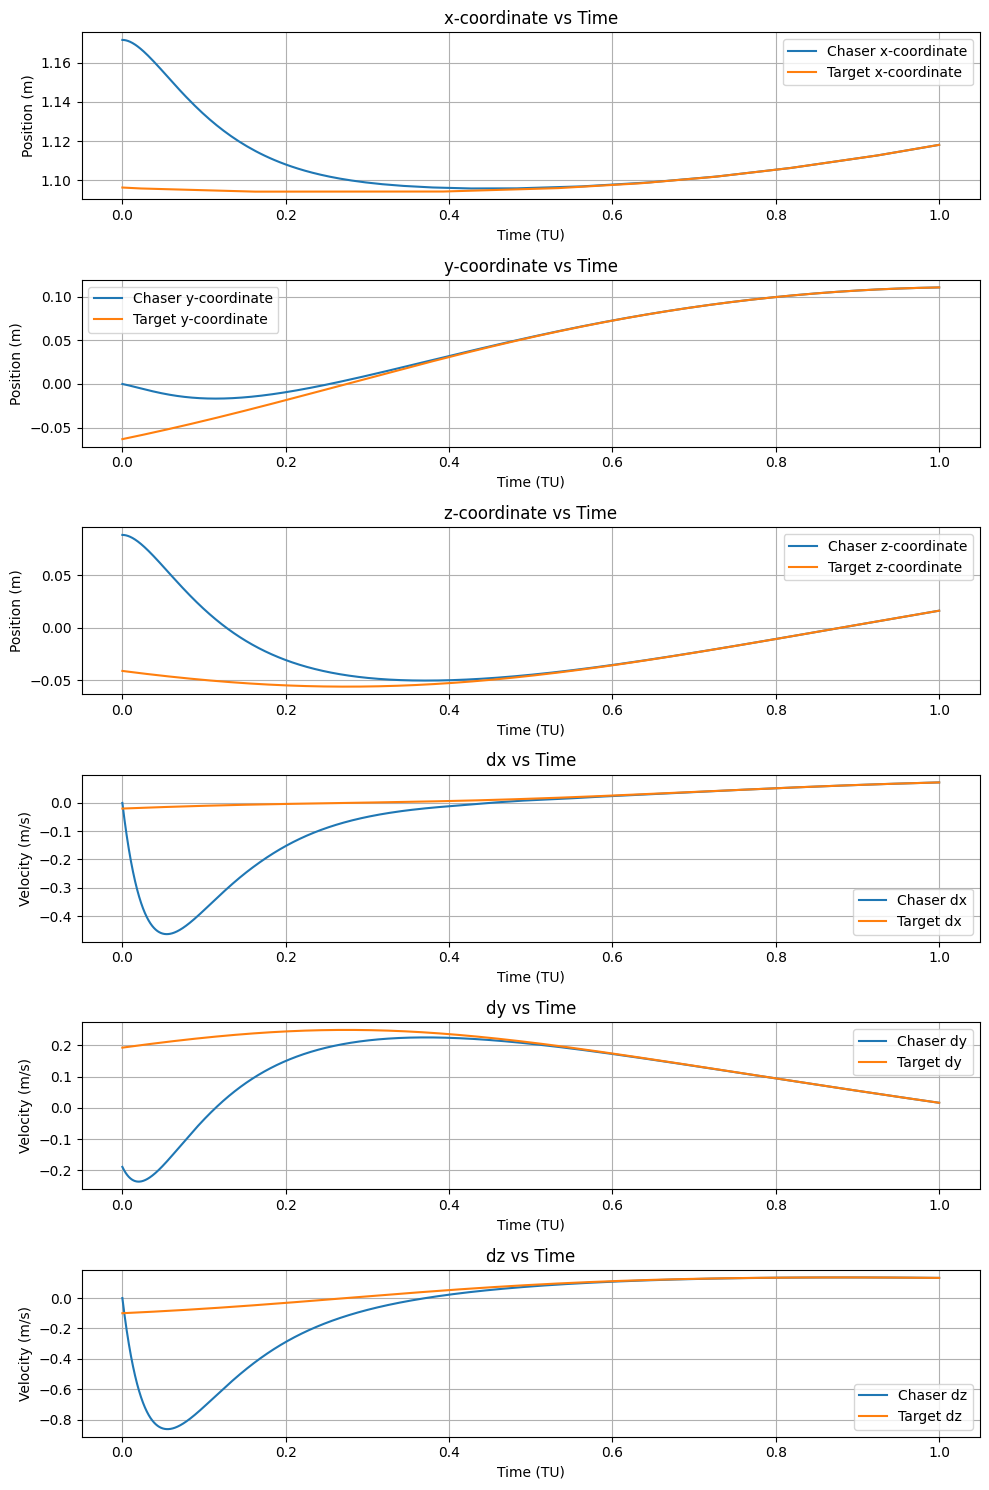

In [9]:
plots = 'both'
time = np.linspace(0, cont.T,len(chaser_states[:, 0]))
if plots == 'both':
  fig, axs = plt.subplots(6, 1, figsize=(10, 15))

  titles = ['x-coordinate', 'y-coordinate', 'z-coordinate', 'dx', 'dy', 'dz']
  y_labels = ['Position (m)', 'Position (m)', 'Position (m)', 'Velocity (m/s)', 'Velocity (m/s)', 'Velocity (m/s)']

  for i in range(6):
      axs[i].plot(time, chaser_states[:, i].cpu().numpy(), label='Chaser ' + titles[i])
      axs[i].plot(time, target_states[:, i].cpu().numpy(), label='Target ' + titles[i])
      axs[i].set_xlabel('Time (TU)')
      axs[i].set_ylabel(y_labels[i])
      axs[i].set_title(titles[i] + ' vs Time')
      axs[i].legend()
      axs[i].grid(True)


else:
  fig, axs = plt.subplots(6, 1, figsize=(10, 15))

  titles = ['x-coordinate', 'y-coordinate', 'z-coordinate', 'dx', 'dy', 'dz']
  y_label_p = 'Error(m)'
  y_label_v = 'Error(m/s)'
  chaser_states[:,:3],  target_states[:, :3]  = chaser_states[:,:3].clone() * env.DU * 1000,  target_states[:, :3].clone() * env.DU * 1000
  chaser_states[:,3:],  target_states[:, 3:]  = chaser_states[:,3:].clone() * env.DU / env.TU * 1000,  target_states[:, 3:].clone() * env.DU * 1000 / env.TU
  for i in range(6):
      axs[i].plot(time, target_states[:, i].cpu().numpy()-chaser_states[:, i].cpu().numpy(), label='Chaser ' + titles[i])
      axs[i].set_xlabel('Time (TU)')
      if i<3:
        axs[i].set_ylabel(y_label_p)
      else:
        axs[i].set_ylabel(y_label_v)
      axs[i].set_title(titles[i] + ' vs Time')
      axs[i].grid(True)

plt.tight_layout()

plt.show()